# Comparação entre os grupos (Cooperative waste pickers vs. Independent waste pickers) para os domínios do WHO-Qol

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [31]:
caminho = r'C:\Users\saulosgil\OneDrive\Documentos\health_outcomes_workers\data\df_analise.csv'
df = pd.read_csv(caminho)

df.head()

,idade,sexo,estado_civil,escolaridade,renda_mensal,cor_raca,tempo_trab_anos,funcao_trab,carga_horaria_horas_sem,outro_trab,...,Diuretics,Beta_blockers,ACE_inhibitors,Metformin,CCB,whoqol_fisico,whoqol_psicologico,whoqol_social,whoqol_ambiente,whoqol_n_validos
0,34,feminino,separado,médio completo,1 a 3 salários mínimos,preto (a),1.0,cooperado,40,sim,...,0,0,0,0,0,71.43,70.83,83.33,78.12,26
1,59,masculino,divorciado,médio completo,mais de 3 salários,pardo (a),2.0,cooperado,56,não,...,0,0,0,0,0,100.00,83.33,100.00,93.75,26
2,27,masculino,solteiro,superior completo,mais de 3 salários,pardo (a),1.0,cooperado,44,não,...,0,0,0,0,0,78.57,58.33,75.00,75.00,26
3,40,masculino,solteiro,médio completo,1 a 3 salários mínimos,preto (a),1.0,cooperado,45,não,...,0,0,0,0,0,78.57,95.83,100.00,78.12,26
4,23,masculino,solteiro,médio completo,mais de 3 salários,preto (a),2.0,cooperado,45,não,...,0,0,0,0,0,75.00,83.33,66.67,90.62,26


# Calculo dos valores médio de cada dominio do WHO-Qol

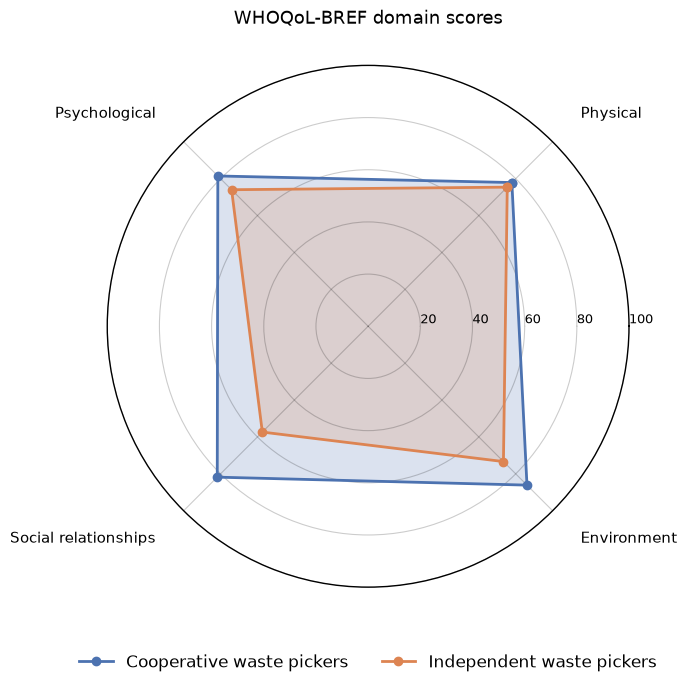

In [32]:
# ── Dados: média de cada domínio por grupo ─────────────────────────
df['funcao_trab'] = df['funcao_trab'].replace({
    'cooperado':   'Cooperative waste pickers',
    'individual':  'Independent waste pickers',
    'Cooperative': 'Cooperative waste pickers',
    'Independent': 'Independent waste pickers',
})

dominios = {
    'whoqol_fisico':      'Physical',
    'whoqol_psicologico': 'Psychological',
    'whoqol_social':      'Social relationships',
    'whoqol_ambiente':    'Environment',
}

medias = df.groupby('funcao_trab')[list(dominios)].mean()


grupos = {
    'Cooperative waste pickers': '#4C72B0',   # mesmas cores da Figura 1
    'Independent waste pickers': '#DD8452',
}

rotulos = list(dominios.values())
n = len(rotulos)

# Ângulos começando em 45° → domínios nas diagonais, eixo horizontal livre para a escala
angles = np.linspace(0, 2 * np.pi, n, endpoint=False) + np.pi / 4
angles_fechado = np.append(angles, angles[0])

# ── Figura ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})

for grupo, cor in grupos.items():
    valores = medias.loc[grupo].values
    valores_fechado = np.append(valores, valores[0])   # não altera a lista original

    ax.plot(angles_fechado, valores_fechado, color=cor, linewidth=2,
            marker='o', markersize=6, label=grupo)
    ax.fill(angles_fechado, valores_fechado, color=cor, alpha=0.20)

# Rótulos dos domínios, alinhados para fora do círculo
ax.set_xticks(angles)
ax.set_xticklabels(rotulos, fontsize=11)
ax.tick_params(axis='x', pad=18)
for label, ang in zip(ax.get_xticklabels(), angles):
    label.set_horizontalalignment('left' if np.cos(ang) > 0 else 'right')

# Escala radial na horizontal (ângulo 0°), sem sobrepor os domínios
ax.set_ylim(0, 100)
ax.set_yticks(range(20, 101, 20))
ax.set_yticklabels([str(v) for v in range(20, 101, 20)], fontsize=9, color='black')
ax.set_rlabel_position(0)

# Grid e contorno em preto suave, como nas outras figuras
ax.grid(color='black', alpha=0.2)
ax.spines['polar'].set_color('black')
ax.spines['polar'].set_linewidth(1)

# Legenda no canto superior esquerdo, fora da área do radar
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), ncol=2, frameon=False, fontsize=12)

ax.set_title('WHOQoL-BREF domain scores', fontsize=13, pad=30)

plt.tight_layout()
plt.savefig('figura_2/radar_whoqol.png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
from statsmodels.stats.weightstats import ttest_ind, CompareMeans, DescrStatsW

variaveis = ['whoqol_fisico', 'whoqol_psicologico', 'whoqol_social', 'whoqol_ambiente']

resultados = []

for var in variaveis:
    grupo1 = df.loc[df['funcao_trab'] == 'Independent waste pickers', var].dropna()
    grupo2 = df.loc[df['funcao_trab'] == 'Cooperative waste pickers',  var].dropna()

    cm = CompareMeans(DescrStatsW(grupo1), DescrStatsW(grupo2))
    t, p, gl = ttest_ind(grupo1, grupo2, usevar='unequal')
    ic_inf, ic_sup = cm.tconfint_diff(alpha=0.05, usevar='unequal')
    delta = grupo1.mean() - grupo2.mean()

    # Saída no console
    # status = 'Há' if p < 0.05 else 'Não há'
    # print(f'{var}: {status} diferença estatisticamente significante')
    # print(f'  Δ: {delta:.1f} (IC 95%: {ic_inf:.1f} a {ic_sup:.1f}), P = {p:.4f}\n')

    # Guarda na tabela
    resultados.append({
        'variavel': var,
        'independent (média ± DP)': f'{grupo1.mean():.1f} ± {grupo1.std():.1f}',
        'cooperative (média ± DP)': f'{grupo2.mean():.1f} ± {grupo2.std():.1f}',
        'Δ (IC 95%)': f'{delta:.1f} ({ic_inf:.1f} a {ic_sup:.1f})',
        't': round(t, 2),
        'gl': round(gl, 1),
        'P': round(p, 4),
    })

tabela_t = pd.DataFrame(resultados)
tabela_t

,variavel,independent (média ± DP),cooperative (média ± DP),Δ (IC 95%),t,gl,P
0,whoqol_fisico,75.4 ± 21.3,77.9 ± 14.1,-2.5 (-14.5 a 9.5),-0.43,24.8,0.6734
1,whoqol_psicologico,74.0 ± 17.6,81.5 ± 15.8,-7.5 (-18.2 a 3.2),-1.42,31.3,0.1654
2,whoqol_social,57.4 ± 31.4,81.8 ± 19.9,-24.4 (-42.0 a -6.8),-2.86,24.1,0.0085
3,whoqol_ambiente,73.3 ± 18.5,86.1 ± 12.6,-12.8 (-23.3 a -2.3),-2.50,25.4,0.0192
